In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("../data/processed/ai_job_dataset_cleaned.csv")
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,skills_list
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics,"['Tableau', 'PyTorch', 'Kubernetes', 'Linux', ..."
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,"['Deep Learning', 'AWS', 'Mathematics', 'Pytho..."
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech,"['Kubernetes', 'Deep Learning', 'Java', 'Hadoo..."
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems,"['Scala', 'SQL', 'Linux', 'Python']"
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics,"['MLOps', 'Java', 'Tableau', 'Python']"


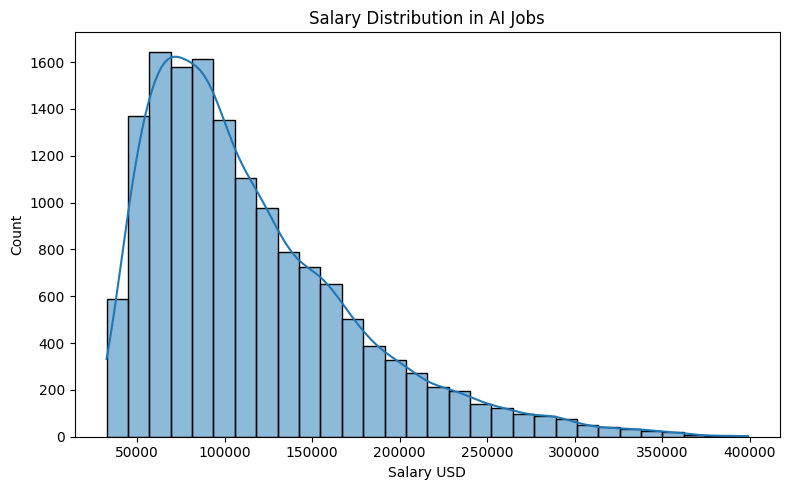

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["salary_usd"], bins=30, kde=True)
plt.title("Salary Distribution in AI Jobs")
plt.xlabel("Salary USD")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/figures/salary_distribution.png")
plt.show()

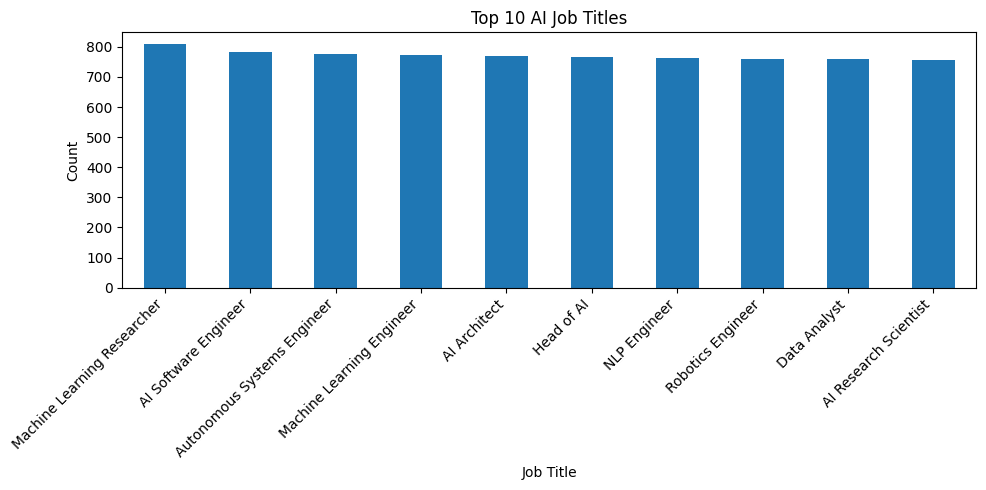

In [12]:
top_jobs = df["job_title"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_jobs.plot(kind="bar")
plt.title("Top 10 AI Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/top_job_titles.png")
plt.show()

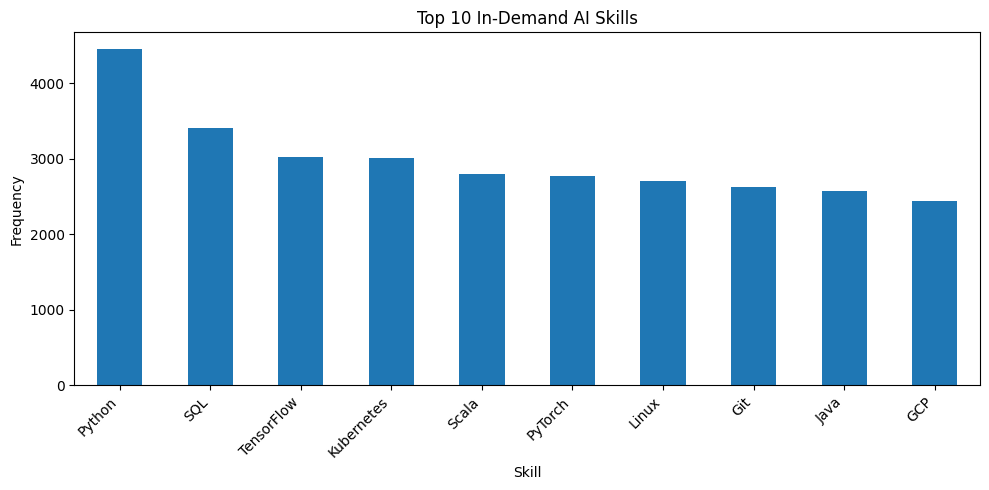

In [13]:
skills_df = df.copy()
skills_df["skills_list"] = skills_df["required_skills"].astype(str).apply(lambda x: [skill.strip() for skill in x.split(",")])
skills_df = skills_df.explode("skills_list")

top_skills = skills_df["skills_list"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_skills.plot(kind="bar")
plt.title("Top 10 In-Demand AI Skills")
plt.xlabel("Skill")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/top_skills.png")
plt.show()

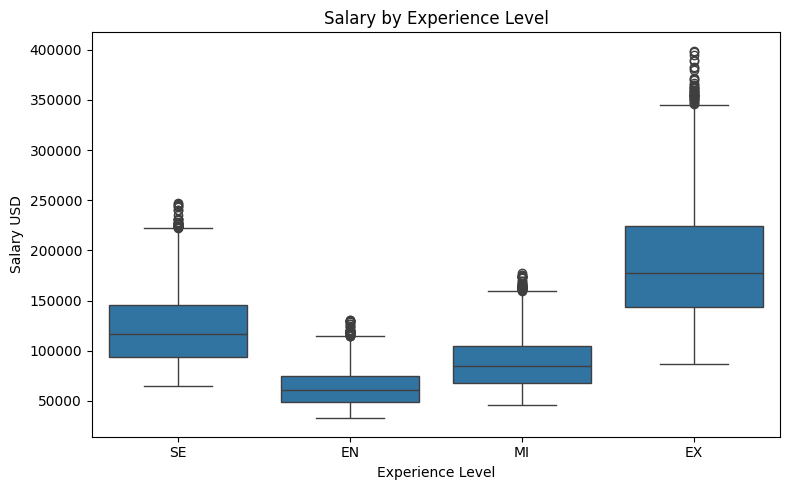

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="experience_level", y="salary_usd")
plt.title("Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary USD")
plt.tight_layout()
plt.savefig("../outputs/figures/salary_by_experience.png")
plt.show()

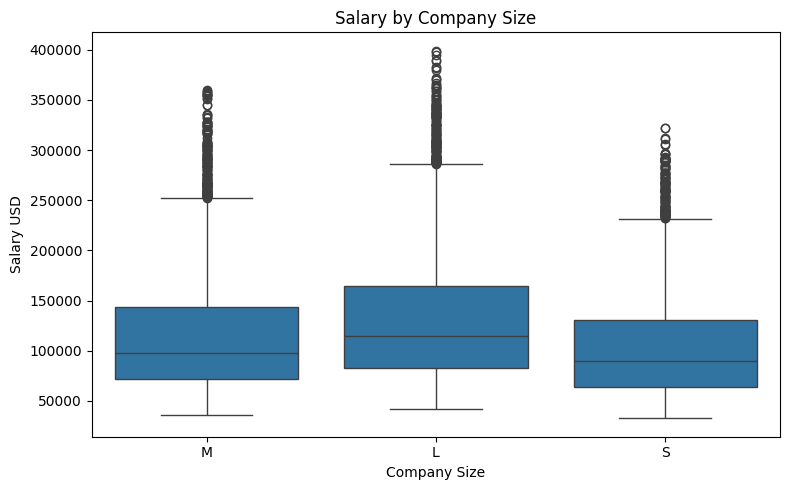

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="company_size", y="salary_usd")
plt.title("Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Salary USD")
plt.tight_layout()
plt.savefig("../outputs/figures/salary_by_company_size.png")
plt.show()

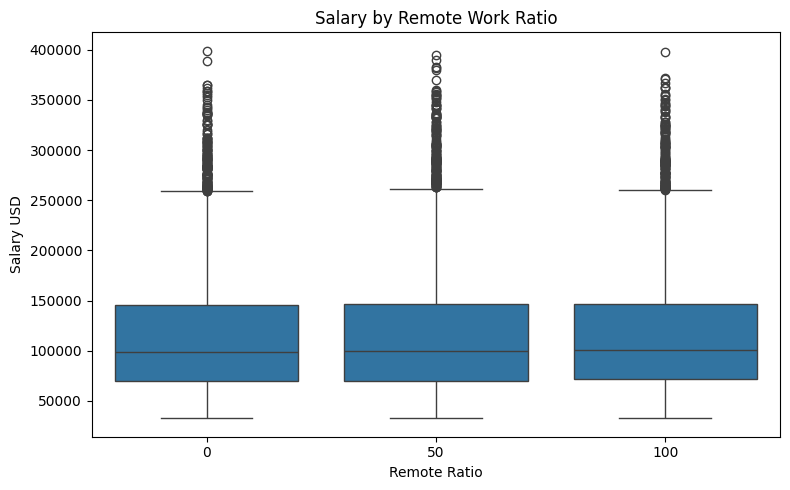

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="remote_ratio", y="salary_usd")
plt.title("Salary by Remote Work Ratio")
plt.xlabel("Remote Ratio")
plt.ylabel("Salary USD")
plt.tight_layout()
plt.savefig("../outputs/figures/salary_by_remote_ratio.png")
plt.show()

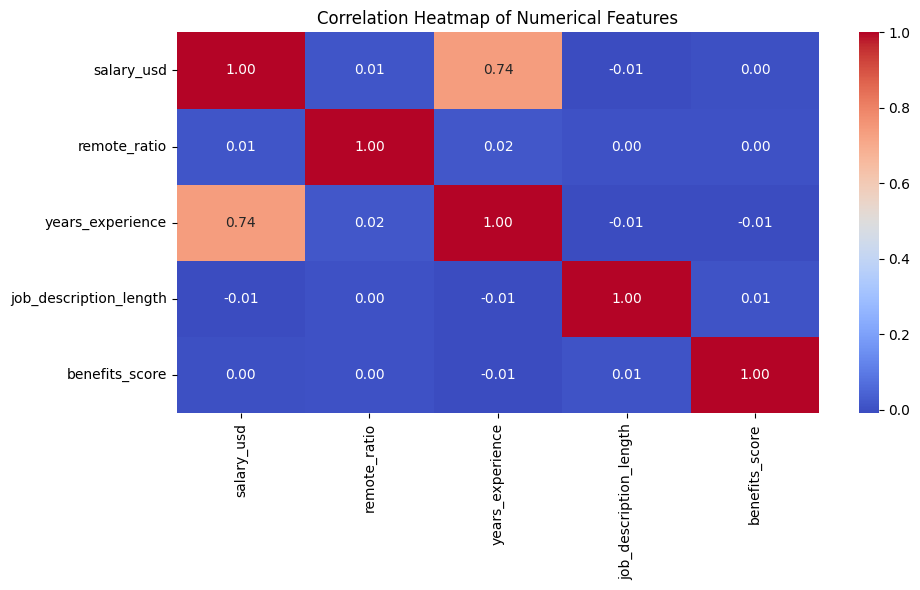

In [17]:
# Correlation heatmap for numerical variables

plt.figure(figsize=(10, 6))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_heatmap.png")
plt.show()

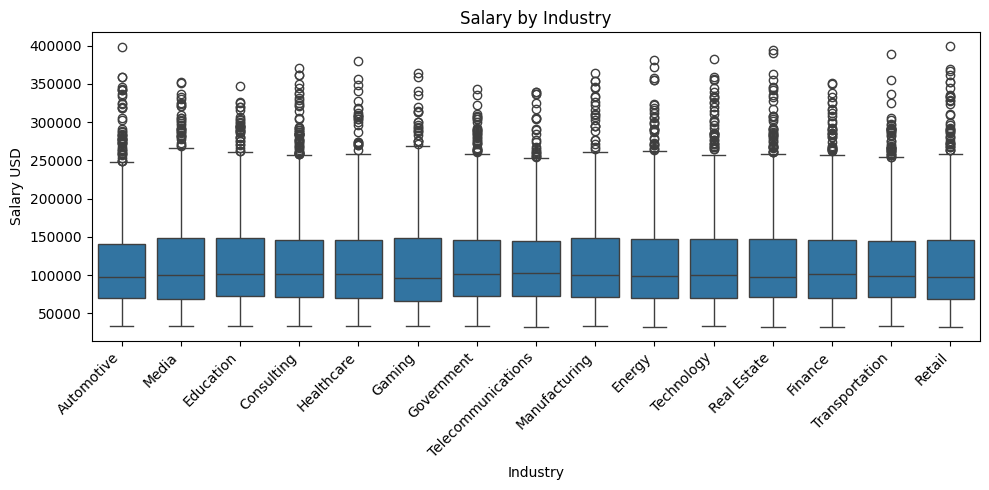

In [18]:
# Salary comparison by industry

plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="industry", y="salary_usd")

plt.title("Salary by Industry")
plt.xlabel("Industry")
plt.ylabel("Salary USD")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../outputs/figures/salary_by_industry.png")
plt.show()